<a href="https://colab.research.google.com/github/ShashikanthKungulwar/CV_practice/blob/main/cifar10_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [71]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader

from torchvision import transforms
from torchvision.datasets import CIFAR10
import matplotlib.pyplot as plt

In [72]:
transform = transforms.Compose(
    [transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.4914, 0.4822, 0.4465],
        std = [0.2470, 0.2435, 0.2616]
    )]
)

train_data = CIFAR10(download=True,root = "data/train",train=True,transform=transform)
test_data = CIFAR10(download=True,root = "data/test",train=False,transform=transform)


In [73]:
!pwd

/content


In [74]:
!ls

data  sample_data


In [75]:
train_size = int(len(train_data)*0.8)
val_size = len(train_data) - train_size

In [76]:
train_size

40000

In [77]:
from torch.utils.data import random_split
train_data,val_data = random_split(train_data,[train_size,val_size])

In [78]:
train_dataloader = DataLoader(train_data,batch_size=64,shuffle=True)
val_dataloader = DataLoader(val_data,batch_size=64,shuffle=True)
test_dataloader = DataLoader(test_data,batch_size=1000,shuffle=False)

In [79]:
len(train_dataloader)

625

In [80]:
for batch,(x_train,y_train) in enumerate(train_dataloader):
    print(x_train.shape)
    print(y_train.shape)
    break

torch.Size([64, 3, 32, 32])
torch.Size([64])


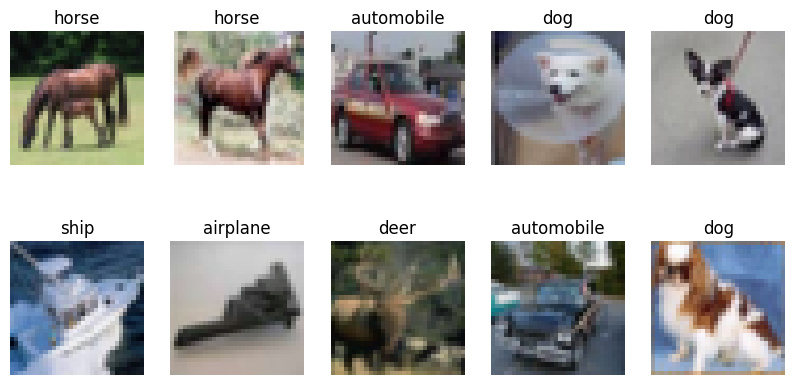

In [81]:


labels=["airplane",
"automobile",
"bird",
"cat",
"deer",
"dog",
"frog",
"horse",
"ship",
"truck"]



for batch,(x_train,y_train) in enumerate(train_dataloader):
    fig,axes = plt.subplots(2,5,figsize=(10,5))
    mean=[0.4914, 0.4822, 0.4465]
    std = [0.2470, 0.2435, 0.2616]
    for i in range(10):
      ax = axes[i//5,i%5]
      ax.imshow((x_train[i].permute(1,2,0).numpy()*std+mean).clip(0,1))
      ax.set_title(labels[y_train[i].item()])
      ax.axis("off")
    plt.show()

    break

In [91]:
# model architecture

class CNNModel(nn.Module):
    def __init__(self,num_classes):
        super(CNNModel,self).__init__()
        self.num_classes = num_classes
        self.conv1 = nn.Conv2d(in_channels = 3,out_channels=32,kernel_size=3)
        self.conv2 = nn.Conv2d(in_channels = 32,out_channels=64,kernel_size=3)
        self.dropout1 = nn.Dropout(p=0.25)


        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(in_features=6*6*64,out_features=128)
        self.dropout2 = nn.Dropout(p=0.5)
        self.fc2 = nn.Linear(in_features=128,out_features=self.num_classes)
    def forward(self,x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x,2)
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x,2)
        x = self.dropout1(x)

        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = self.dropout2(x)

        logits = self.fc2(x)
        return logits

In [97]:
model  = CNNModel(num_classes=10)


In [98]:
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr=1e-3)

In [99]:
def train(epoch):
  model.train()
  correct = 0
  total = 0
  batches = len(train_dataloader)
  total_loss = 0
  for batch,(x_train,y_train) in enumerate(train_dataloader):
    y_pred = model(x_train)
    loss = loss_fn(y_pred,y_train)


    optimizer.zero_grad()
    loss.backward()
    optimizer.step()


    correct += (y_pred.argmax(dim = 1) == y_train).sum().item()
    total += y_train.size()[0]
    total_loss += (loss.item()*len(y_train))
    if batch % 100 == 0:
      print(f"batch : [{batch+1} / {batches}]    loss = {loss.item()}")

  print(f"train accuracy : {correct/total} train loss : {total_loss/total}")


  model.eval()
  correct = 0
  total = 0
  val_loss = 0
  with torch.no_grad():
    for batch,(x_val,y_val) in enumerate(val_dataloader):
      y_pred = model(x_val)
      loss = loss_fn(y_pred,y_val)

      correct += (y_pred.argmax(dim = 1) == y_val).sum().item()
      total += len(y_val)
      val_loss += (loss.item()*len(y_val))

  print(f"val accuracy : {correct/total} val loss : {val_loss/total}")




In [100]:
def test():
  model.eval()
  correct = 0
  total = 0
  total_loss = 0
  with torch.no_grad():
    for batch,(x_test,y_test) in enumerate(test_dataloader):
      y_pred = model(x_test)
      loss = loss_fn(y_pred,y_test)

      correct += (y_pred.argmax(dim = 1) == y_test).sum().item()
      total += len(y_test)
      total_loss += (loss.item()*len(y_test))

  print(f"val accuracy : {correct/total} test loss : {total_loss/total}")

In [101]:
epochs = 10
for epoch in range(epochs):
  print(f"epoch : {epoch+1} ------------------------------------------------------------")
  train(epoch)
test()

epoch : 1 ------------------------------------------------------------
batch : [1 / 625]    loss = 2.3042609691619873
batch : [101 / 625]    loss = 1.7734184265136719
batch : [201 / 625]    loss = 1.5011754035949707
batch : [301 / 625]    loss = 1.5760959386825562
batch : [401 / 625]    loss = 1.4702926874160767
batch : [501 / 625]    loss = 1.3521965742111206
batch : [601 / 625]    loss = 1.614554524421692
train accuracy : 0.41685 train loss : 1.598555820083618
val accuracy : 0.5494 val loss : 1.258755178451538
epoch : 2 ------------------------------------------------------------
batch : [1 / 625]    loss = 1.3780384063720703
batch : [101 / 625]    loss = 1.0302090644836426
batch : [201 / 625]    loss = 1.3719053268432617
batch : [301 / 625]    loss = 1.2266935110092163
batch : [401 / 625]    loss = 1.2834440469741821
batch : [501 / 625]    loss = 1.1367861032485962
batch : [601 / 625]    loss = 1.1079336404800415
train accuracy : 0.535675 train loss : 1.2996843612670899
val accuracy

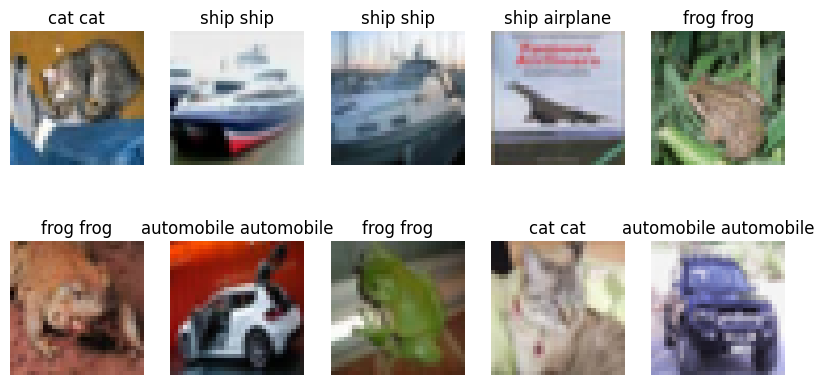

In [105]:
for batch,(x_test,y_test) in enumerate(test_dataloader):
    fig,axes = plt.subplots(2,5,figsize=(10,5))
    y_pred = model(x_test)
    y_pred = torch.argmax(y_pred,dim=1)

    mean=[0.4914, 0.4822, 0.4465]
    std = [0.2470, 0.2435, 0.2616]
    for i in range(10):
      ax = axes[i//5,i%5]
      ax.imshow((x_test[i].permute(1,2,0).numpy()*std+mean).clip(0,1))
      ax.set_title(labels[y_pred[i].item()]+" "+labels[y_test[i].item()])
      ax.axis("off")
    plt.show()

    break

In [107]:
torch.save(
    {
        "model_state_dict":model.state_dict(),
        "optimizer_state_dict":optimizer.state_dict()
    },
    "model.pth"
)

In [109]:
model2 = CNNModel(num_classes=10)
model2.load_state_dict(torch.load("model.pth")["model_state_dict"])

<All keys matched successfully>

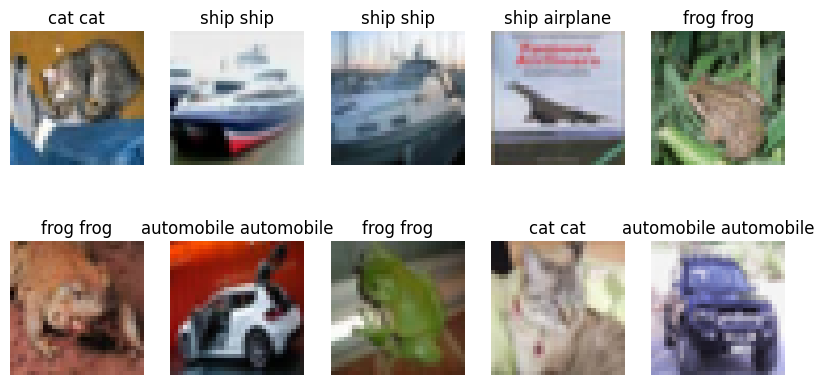

In [110]:
for batch,(x_test,y_test) in enumerate(test_dataloader):
    fig,axes = plt.subplots(2,5,figsize=(10,5))
    y_pred = model2(x_test)
    y_pred = torch.argmax(y_pred,dim=1)

    mean=[0.4914, 0.4822, 0.4465]
    std = [0.2470, 0.2435, 0.2616]
    for i in range(10):
      ax = axes[i//5,i%5]
      ax.imshow((x_test[i].permute(1,2,0).numpy()*std+mean).clip(0,1))
      ax.set_title(labels[y_pred[i].item()]+" "+labels[y_test[i].item()])
      ax.axis("off")
    plt.show()

    break

In [ ]:
# calculation of mean , std of channes code

In [111]:
train_data = CIFAR10(download=True,root = "data/train",train=True,transform=transforms.ToTensor())
test_data = CIFAR10(download=True,root = "data/test",train=False,transform=transforms.ToTensor())

In [115]:
dict(train_data).keys()

KeyboardInterrupt: 

In [116]:
train_data_x = train_data.data

In [117]:
len(train_data_x)

50000

In [118]:
type(train_data_x)

numpy.ndarray

In [119]:
train_data_x.shape

(50000, 32, 32, 3)

In [124]:
r_channel_mean = train_data_x[:,:,:,0]

In [126]:
r_channel_mean.flatten().mean()

np.float64(125.306918046875)

In [127]:
mean = train_data_x.mean(axis=(0,1,2))
std  = train_data_x.std(axis=(0,1,2))

In [128]:
mean

array([125.30691805, 122.95039414, 113.86538318])

In [130]:
train_dataloader = DataLoader(train_data,batch_size=64,shuffle=True)
# val_dataloader = DataLoader(val_data,batch_size=64,shuffle=True)
test_dataloader = DataLoader(test_data,batch_size=1000,shuffle=False)

In [131]:
mean = 0.
std = 0.
total_images = 0

for images, _ in train_dataloader:
    # images shape: (B, C, H, W)

    batch_size = images.size(0)
    images = images.view(batch_size, images.size(1), -1)  # (B, C, H*W)

    mean += images.mean(2).sum(0)
    std  += images.std(2).sum(0)

    total_images += batch_size

mean /= total_images
std  /= total_images

print("Mean:", mean)
print("Std :", std)

Mean: tensor([0.4914, 0.4822, 0.4465])
Std : tensor([0.2023, 0.1994, 0.2010])
